In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['lines.linewidth'] = 2

В модели Солоу мы работаем с относительными показателями. Нас интересует динамика капиталовооруженности $k = K/L$ (сколько оборудования приходится на одного рабочего).

Производственная функция Кобба-Дугласа в интенсивной форме (на одного работника):
$$x = f(k) = A k^\alpha$$

Для варианта №2:
$$F(K, L) = 2K^{3/4}L^{1/4} \implies x = 2k^{0.75}$$
Где $A = 2$ (общая факторная производительность) и $\alpha = 0.75$ (эластичность выпуска по капиталу).

Дифференциальное уравнение, описывающее динамику капиталовооруженности:
$$\frac{dk}{dt} = \rho A k^\alpha - \lambda k$$
Где:
- $\rho A k^\alpha$ — удельные инвестиции.
- $\lambda = \mu + v$ — эффективная норма выбытия (0.05 + 0.02 = 0.07).

### Задание 1. Аналитическое решение

Уравнение Бернулли, представленное выше, сводится к линейному через замену переменных. Аналитическое решение (траектория развития экономики во времени) имеет вид:

$$k(t) = \left[ (k^*)^{1-\alpha} + \left(k_0^{1-\alpha} - (k^*)^{1-\alpha}\right) e^{-(1-\alpha)\lambda t} \right]^{\frac{1}{1-\alpha}}$$

Где $k^*$ — стационарный уровень, а $k_0$ — начальный капитал.

### Задание 2. Стационарный уровень и точка перегиба

Стационарный уровень $k^*$ достигается, когда $\frac{dk}{dt} = 0$:
$$\rho A (k^*)^\alpha = \lambda k^* \implies k^* = \left( \frac{\rho A}{\lambda} \right)^{\frac{1}{1-\alpha}}$$

Точка перегиба $\tilde{k}$ (момент, когда ускоренный рост сменяется замедляющимся) находится из условия $\frac{d^2k}{dt^2} = 0$:
$$\tilde{k} = \left( \frac{\alpha \rho A}{\lambda} \right)^{\frac{1}{1-\alpha}}$$

In [6]:
class SolowModel:
    def __init__(self, A: float, alpha: float, mu: float, v: float, rho: float):
        self.A = A
        self.alpha = alpha
        self.mu = mu
        self.v = v
        self.rho = rho
        self.lambda_ = mu + v
        
    def steady_state(self) -> float:
        """Расчет стационарного уровня капиталовооруженности."""
        return ( (self.rho * self.A) / self.lambda_ ) ** (1 / (1 - self.alpha))
    
    def inflection_point(self) -> float:
        """Расчет точки перегиба траектории."""
        return ( (self.alpha * self.rho * self.A) / self.lambda_ ) ** (1 / (1 - self.alpha))
    
    def calculate_trajectory(self, k0: float, t_array: np.ndarray) -> np.ndarray:
        """Расчет аналитической траектории k(t)."""
        k_star = self.steady_state()
        power = 1 - self.alpha
        exponent = np.exp(-power * self.lambda_ * t_array)
        
        # Реализация аналитического решения
        term1 = k_star ** power
        term2 = (k0 ** power - k_star ** power) * exponent
        
        return (term1 + term2) ** (1 / power)

# Исходные данные варианта 2
model_base = SolowModel(A=2.0, alpha=0.75, mu=0.05, v=0.02, rho=0.1)

k_star_base = model_base.steady_state()
k_inflection_base = model_base.inflection_point()

print(f"Стационарный уровень (k*): {k_star_base:.2f}")
print(f"Точка перегиба (k_tilde): {k_inflection_base:.2f}")

Стационарный уровень (k*): 66.64
Точка перегиба (k_tilde): 21.08


### Задание 3. Анализ переходных процессов и траектории

В зависимости от начального состояния $k_0$, система ведет себя по-разному:
1. **Ускоренный рост:** $k_0 < \tilde{k}$. Экономика бедна, отдача от новых станков колоссальна, рост инвестиций опережает рост выбытия с ускорением.
2. **Замедляющийся рост:** $\tilde{k} < k_0 < k^*$. Капитала уже много. Рост продолжается, но закон убывающей предельной полезности берет свое — каждый новый станок дает меньше прироста ВВП.
3. **Экономический спад (проедание фондов):** $k_0 > k^*$. Экономика переинвестирована. Износ такого огромного количества оборудования превышает возможности экономики по его ремонту и обновлению. Капитал падает до $k^*$.

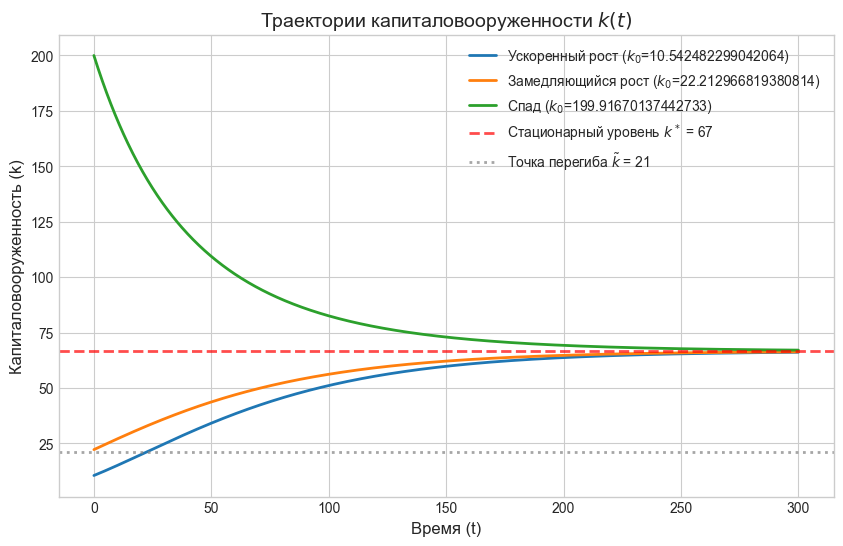

In [13]:
# Задаем временной горизонт
# Берем большой промежуток (500 лет), так как при alpha=0.75 сходимость очень медленная
t = np.linspace(0, 300, 1000)

# Выбираем начальные условия согласно анализу
k0_accelerated = k_inflection_base/2       # k0 < k_tilde
k0_decelerated = k_star_base/3      # k_tilde < k0 < k*
k0_decline = k_star_base*3        # k0 > k*

# Считаем траектории
traj_acc = model_base.calculate_trajectory(k0_accelerated, t)
traj_dec = model_base.calculate_trajectory(k0_decelerated, t)
traj_dec_line = model_base.calculate_trajectory(k0_decline, t)

plt.figure()
plt.plot(t, traj_acc, label=f'Ускоренный рост ($k_0$={k0_accelerated})')
plt.plot(t, traj_dec, label=f'Замедляющийся рост ($k_0$={k0_decelerated})')
plt.plot(t, traj_dec_line, label=f'Спад ($k_0$={k0_decline})')

# Линии асимптоты и перегиба
plt.axhline(k_star_base, color='red', linestyle='--', alpha=0.7, label=f'Стационарный уровень $k^*$ = {k_star_base:.0f}')
plt.axhline(k_inflection_base, color='gray', linestyle=':', alpha=0.7, label=f'Точка перегиба $\\tilde{{k}}$ = {k_inflection_base:.0f}')

plt.title("Траектории капиталовооруженности $k(t)$")
plt.xlabel("Время (t)")
plt.ylabel("Капиталовооруженность (k)")
plt.legend()
plt.show()

### Задание 4. Влияние эластичности $\alpha$

Увеличим $\alpha$ на 10%. 
Новое значение: $\alpha_{new} = 0.75 \times 1.10 = 0.825$.

Эластичность $\alpha$ показывает, насколько сильно выпуск реагирует на увеличение капитала. Рост $\alpha$ означает технологический сдвиг: теперь капитал играет еще более важную роль в производстве (например, массовая автоматизация). Математически, в формуле знаменатель степени $(1-\alpha)$ становится еще меньше, что приведет к взрывному росту $k^*$.

Старый стационарный уровень: 66.64
Новый стационарный уровень (при альфа +10%): 403.02


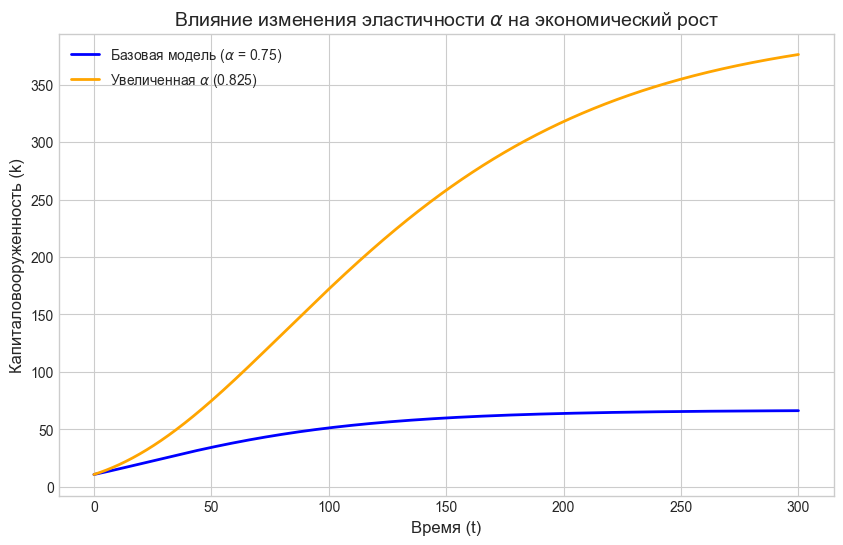

: 

In [ ]:
alpha_new = 0.75 * 1.1
model_alpha = SolowModel(A=2.0, alpha=alpha_new, mu=0.05, v=0.02, rho=0.1)

k_star_alpha = model_alpha.steady_state()
k_inflection_alpha = model_alpha.inflection_point()

print(f"Старый стационарный уровень: {k_star_base:.2f}")
print(f"Новый стационарный уровень (при альфа +10%): {k_star_alpha:.2f}")

traj_alpha = model_alpha.calculate_trajectory(k0_accelerated, t)

plt.figure()
plt.plot(t, traj_acc, label=f'Базовая модель ($\\alpha$ = 0.75)', color='blue')
plt.plot(t, traj_alpha, label=f'Увеличенная $\\alpha$ (0.825)', color='orange')

plt.title("Влияние изменения эластичности $\\alpha$ на экономический рост")
plt.xlabel("Время (t)")
plt.ylabel("Капиталовооруженность (k)")
plt.legend()
# plt.ylim(0, 5000) 
plt.show()

### Задания 5 и 6. Норма накопления и Золотое правило

Теперь исследуем изменение нормы накопления $\rho$ (какую долю ВВП экономика сберегает и инвестирует).

1. **Недонакопление ($\rho < \alpha$):** Например, $\rho = 0.1$. Экономика сберегает слишком мало, уровень капитала низкий, следовательно, и выпуск низкий.
2. **Перенакопление ($\rho > \alpha$):** Например, $\rho = 0.9$. Экономика сберегает почти всё. Капитала колоссально много, но на потребление гражданам почти ничего не остается. ВВП работает на то, чтобы чинить станки.
3. **Оптимальный вариант (Золотое правило, $\rho = \alpha$):** В нашем случае $\rho^* = 0.75$. При таком уровне максимизируется удельное потребление $c^* = (1-\rho)f(k^*)$. То есть экономика накапливает ровно столько, чтобы поддерживать самый высокий уровень жизни населения в долгосрочной перспективе.

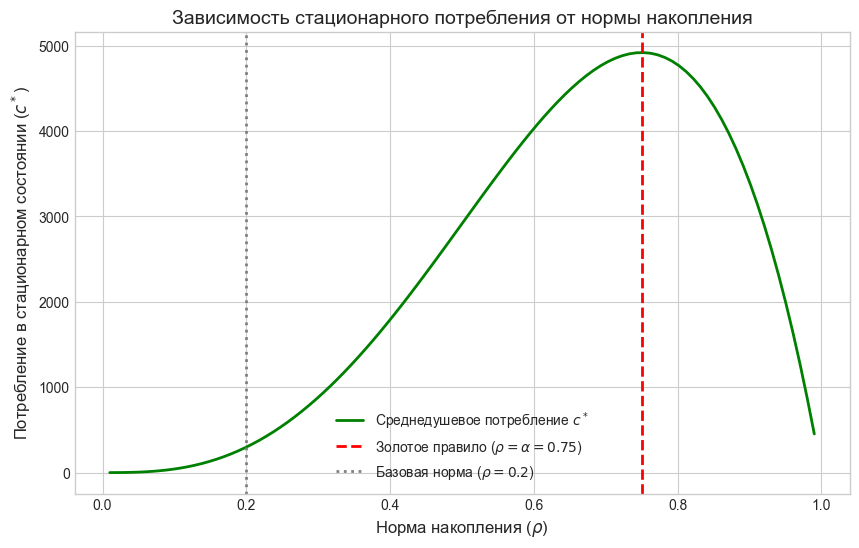

Максимальное потребление 4919.52 достигается при норме накопления rho = 0.75


In [9]:
# Создадим массив возможных норм накопления от 0 до 1
rhos = np.linspace(0.01, 0.99, 100)
consumptions =[]

for r in rhos:
    # Инициализируем модель с текущей нормой накопления
    m = SolowModel(A=2.0, alpha=0.75, mu=0.05, v=0.02, rho=r)
    # Считаем стационарный капитал
    k_st = m.steady_state()
    # Считаем стационарный выпуск
    y_st = m.A * (k_st ** m.alpha)
    # Считаем стационарное потребление c = (1 - rho) * y
    c_st = (1 - r) * y_st
    consumptions.append(c_st)

optimal_rho = rhos[np.argmax(consumptions)]
max_consumption = max(consumptions)

plt.figure()
plt.plot(rhos, consumptions, color='green', label='Среднедушевое потребление $c^*$')
plt.axvline(x=0.75, color='red', linestyle='--', label=f'Золотое правило ($\\rho = \\alpha = 0.75$)')
plt.axvline(x=0.2, color='gray', linestyle=':', label=f'Базовая норма ($\\rho = 0.2$)')

plt.title("Зависимость стационарного потребления от нормы накопления")
plt.xlabel("Норма накопления ($\\rho$)")
plt.ylabel("Потребление в стационарном состоянии ($c^*$)")
plt.legend()
plt.show()

print(f"Максимальное потребление {max_consumption:.2f} достигается при норме накопления rho = {optimal_rho:.2f}")